In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import ast
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.feature_selection import RFE
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, GridSearchCV, GroupShuffleSplit, RandomizedSearchCV, cross_val_score, KFold
from shapely.geometry import LineString, Point
from tqdm import tqdm
from itertools import combinations
from sklearn.neighbors import BallTree
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MinMaxScaler, FunctionTransformer, PolynomialFeatures, RobustScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor, plot_importance, DMatrix, train
from lightgbm import LGBMRegressor
import shap
from scipy.stats import zscore
from scipy.spatial import cKDTree
import os
import fiona
import random
from geopy.distance import geodesic

In [2]:
doubs_data = gpd.read_file("../datasets_par_departement/departement-25-doubs-original.geojson")
caserne = gpd.read_file("../data/caserne/2024_06_21_CIS.shp")
compagnies = gpd.read_file("../data/caserne/2024_06_21_Compagnies.shp")
firepoint_1 = gpd.read_file("../data/hexagones_firepoint_1.geojson")
firepoint_2 = gpd.read_file("../data/hexagones_firepoint_2.geojson")
firepoint_3 = gpd.read_file("../data/hexagones_firepoint_3.geojson")
meteo_doubs = pd.read_csv("../data/meteo/meteostat_doubs.csv")

In [3]:
def calculer_duree(data, colonne_debut, colonne_fin):
    data[colonne_debut] = pd.to_datetime(data[colonne_debut], errors='coerce')
    data[colonne_fin] = pd.to_datetime(data[colonne_fin], errors='coerce')

    data['duree'] = data[colonne_fin] - data[colonne_debut]

    return data

def cyclical_encoding(X, max_value):
    return np.column_stack((
        np.sin(2 * np.pi * X / max_value),
        np.cos(2 * np.pi * X / max_value)
    ))

def season_encoding(month):
    if month in [12, 1, 2]:
        return 0  # Hiver
    elif month in [3, 4, 5]:
        return 1  # Printemps
    elif month in [6, 7, 8]:
        return 2  # Été
    else:
        return 3  # Automne

def remove_highly_correlated_features(X, threshold=0.85):
    corr_matrix = X.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    print(f"🛑 Suppression de {len(to_drop)} features corrélées: {to_drop}")

    return X.drop(columns=to_drop)


doubs_data = calculer_duree(doubs_data, 'date_debut', 'date_fin')
doubs_data['centroid'] = doubs_data.geometry.centroid
doubs_data['centroid_lon'] = doubs_data['centroid'].x
doubs_data['centroid_lat'] = doubs_data['centroid'].y
doubs_data['date_debut'] = pd.to_datetime(doubs_data['date_debut'], errors='coerce')
doubs_data['hour'] = doubs_data['date_debut'].dt.hour
doubs_data['date'] = pd.to_datetime(doubs_data['date'], errors='coerce')
doubs_data['month'] = doubs_data['date'].dt.month
doubs_data['weekday'] = doubs_data['date'].dt.weekday
doubs_data['duree_minutes'] = pd.to_timedelta(doubs_data['duree']).dt.total_seconds() / 60

Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



In [4]:
firepoint = pd.concat([firepoint_1, firepoint_2, firepoint_3], ignore_index=True)
firepoint = firepoint.drop(columns=['geometry'], errors='ignore')

In [5]:
doubs_data = doubs_data.merge(firepoint, on='hex_id', how='left')

threshold = 0.7 * len(doubs_data)
doubs_data.dropna(axis=1, thresh=threshold, inplace=True)

doubs_data.dropna(inplace=True)

In [6]:
doubs_data.shape

(2679, 62)

In [7]:
caserne['compagnie'] = caserne['compagnie'].replace('Maîche', 'Maiche')

caserne = caserne.to_crs(epsg=4326)
caserne["lon"] = caserne.geometry.x
caserne["lat"] = caserne.geometry.y
compagnies = compagnies.to_crs(epsg=4326)

caserne = caserne.merge(compagnies[['id', 'nom']], left_on='compagnie', right_on='nom', how='left')

caserne = caserne.rename(columns={'id': 'id_compagnies'})

if 'nom' in caserne.columns:
    caserne = caserne.drop(columns=['nom'])

none_count = caserne['id_compagnies'].isna().sum()
print(f"Nombre de casernes sans id_compagnies : {none_count}")

print(caserne[['compagnie', 'id_compagnies']].head())

if 'nom_y' in caserne.columns:
    caserne = caserne.drop(columns=['nom_y'])

Nombre de casernes sans id_compagnies : 0
         compagnie  id_compagnies
0         Besançon            1.0
1  Baume-les-Dames            2.0
2      Montbéliard            6.0
3       Pontarlier            4.0
4      Montbéliard            6.0


In [8]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
compagnies = gpd.GeoDataFrame(compagnies, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
compagnies = compagnies.to_crs(epsg=4326)

doubs_data['id_compagnies'] = None

for idx, hexagone in doubs_data.iterrows():
    intersecting_companies = compagnies[compagnies.intersects(hexagone['geometry'])]

    if len(intersecting_companies) == 1:
        doubs_data.at[idx, 'id_compagnies'] = intersecting_companies.iloc[0]['id']
    elif len(intersecting_companies) > 1:
        max_area = 0
        best_company_id = None
        for _, company in intersecting_companies.iterrows():
            intersection = hexagone['geometry'].intersection(company['geometry'])
            area = intersection.area
            if area > max_area:
                max_area = area
                best_company_id = company['id']

        doubs_data.at[idx, 'id_compagnies'] = best_company_id

print(doubs_data[['hex_id', 'id_compagnies']].head())

            hex_id id_compagnies
0  871f820aaffffff           4.0
1  871f82d61ffffff          12.0
2  871f82d61ffffff          12.0
3  871f82d4dffffff           1.0
4  871f82700ffffff           5.0


In [9]:
doubs_data = gpd.GeoDataFrame(doubs_data, geometry='geometry')
caserne = gpd.GeoDataFrame(caserne, geometry='geometry')

doubs_data = doubs_data.to_crs(epsg=4326)
caserne = caserne.to_crs(epsg=4326)

doubs_data['id_caserne'] = None
doubs_data['distance'] = None

for idx, hexagone in doubs_data.iterrows():
    casernes_same_company = caserne[caserne['id_compagnies'] == hexagone['id_compagnies']]

    if casernes_same_company.empty:
        continue

    distances = casernes_same_company.geometry.distance(hexagone['geometry'])

    nearest_caserne_idx = distances.idxmin()
    nearest_caserne = casernes_same_company.loc[nearest_caserne_idx]

    doubs_data.at[idx, 'id_caserne'] = nearest_caserne['id_pg']
    doubs_data.at[idx, 'distance'] = distances.min()

print(doubs_data[['hex_id', 'id_compagnies', 'id_caserne', 'distance']].head())

Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.



            hex_id id_compagnies id_caserne  distance
0  871f820aaffffff           4.0     840709       0.0
1  871f82d61ffffff          12.0     840704  0.005327
2  871f82d61ffffff          12.0     840704  0.005327
3  871f82d4dffffff           1.0     840698  0.039716
4  871f82700ffffff           5.0     840701  0.010387


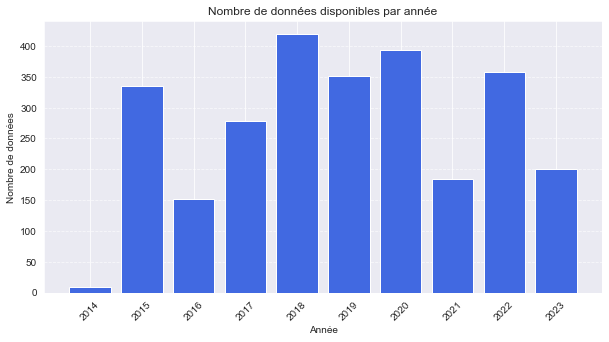

In [10]:
year_counts = doubs_data["year"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index, year_counts.values, color="royalblue")
plt.xlabel("Année")
plt.ylabel("Nombre de données")
plt.title("Nombre de données disponibles par année")
plt.xticks(year_counts.index, rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.show()

In [11]:
print(year_counts)

2014.0      9
2015.0    335
2016.0    152
2017.0    278
2018.0    420
2019.0    351
2020.0    393
2021.0    184
2022.0    357
2023.0    200
Name: year, dtype: int64


In [12]:
doubs_data.columns

Index(['hex_id', 'raison_sortie', 'date_debut', 'date_fin', 'label', 'year',
       'date', 'departement', 'duree_minutes', 'geometry', 'duree', 'centroid',
       'centroid_lon', 'centroid_lat', 'hour', 'month', 'weekday', 'scale0',
       'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI', 'PasDeRoute', 'motorway',
       'primary', 'secondary', 'tertiary', 'path', 'population', 'elevation',
       'foret_encoder', 'highway_encoder', 'PasDeforet', 'Châtaignier',
       'Chênes décidus', 'Conifères', 'Douglas', 'Feuillus', 'Hêtre', 'Mixte',
       'Mélèze', 'NC', 'NR', 'Peuplier', 'Pin autre', 'Pin laricio, pin noir',
       'Pin maritime', 'Pin sylvestre', 'Pins mélangés', 'Robinier',
       'Sapin, épicéa', 'water', 'tree', 'grass', 'crops', 'shrub', 'flooded',
       'built', 'bare', 'snow', 'sinister', 'id_compagnies', 'id_caserne',
       'distance'],
      dtype='object')

In [13]:
cols_to_drop = [
    'raison_sortie', 'label', 'departement', 'duree',
    'index', 'longitude', 'latitude', 'sinister', 'id_caserne', 'date_debut', 'date_fin', 'year', 'scale0', 'hour', 'month', 'weekday', 'distance'
]

doubs_data = doubs_data.drop(columns=[col for col in cols_to_drop if col in doubs_data.columns])

In [14]:
doubs_data.columns

Index(['hex_id', 'date', 'duree_minutes', 'geometry', 'centroid',
       'centroid_lon', 'centroid_lat', 'NDVI', 'NDMI', 'NDBI', 'NDSI', 'NDWI',
       'PasDeRoute', 'motorway', 'primary', 'secondary', 'tertiary', 'path',
       'population', 'elevation', 'foret_encoder', 'highway_encoder',
       'PasDeforet', 'Châtaignier', 'Chênes décidus', 'Conifères', 'Douglas',
       'Feuillus', 'Hêtre', 'Mixte', 'Mélèze', 'NC', 'NR', 'Peuplier',
       'Pin autre', 'Pin laricio, pin noir', 'Pin maritime', 'Pin sylvestre',
       'Pins mélangés', 'Robinier', 'Sapin, épicéa', 'water', 'tree', 'grass',
       'crops', 'shrub', 'flooded', 'built', 'bare', 'snow', 'id_compagnies'],
      dtype='object')

      z  Lower Bound  Upper Bound        MAE       RMSE        R2  \
0   2.0  -193.308183   365.771043  35.301036  49.568009  0.030354   
1   2.1  -207.285164   379.748023  37.570279  50.756412  0.041264   
2   2.2  -221.262145   393.725004  37.570279  50.756412  0.041264   
3   2.3  -235.239125   407.701985  37.456715  51.824335  0.063704   
4   2.4  -249.216106   421.678965  38.777120  55.530498  0.042433   
5   2.5  -263.193087   435.655946  37.191344  54.357449  0.082462   
6   2.6  -277.170067   449.632927  37.416691  53.991449 -0.016037   
7   2.7  -291.147048   463.609907  36.014943  52.960120  0.022409   
8   2.8  -305.124029   477.586888  36.578454  55.067346  0.026893   
9   2.9  -319.101009   491.563869  36.578454  55.067346  0.026893   
10  3.0  -333.077990   505.540849  37.234171  57.746589  0.023126   
11  3.1  -347.054971   519.517830  36.426815  56.146294  0.076518   
12  3.2  -361.031951   533.494811  37.683943  57.799374  0.021339   
13  3.3  -375.008932   547.471791 

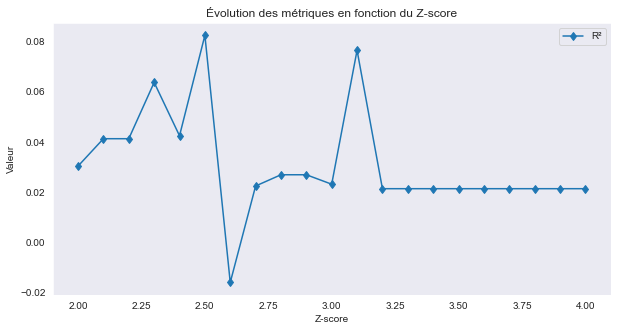

In [15]:
df = doubs_data.copy()

results = []

z_values = np.arange(2.0, 4.1, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    lower_bound = df_filtered['duree_minutes'].mean() - z * df_filtered['duree_minutes'].std()
    upper_bound = df_filtered['duree_minutes'].mean() + z * df_filtered['duree_minutes'].std()

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_percentage = (excluded_count / total_before) * 100

    hex_ids = df_filtered['hex_id'].unique()
    hex_train, hex_test = train_test_split(hex_ids, test_size=0.2, random_state=42)

    train_data = df_filtered[df_filtered['hex_id'].isin(hex_train)]
    test_data = df_filtered[df_filtered['hex_id'].isin(hex_test)]

    X_train, y_train = train_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), train_data['duree_minutes']
    X_test, y_test = test_data.drop(columns=['duree_minutes', 'hex_id', 'geometry', 'centroid', 'date', 'id_compagnies']), test_data['duree_minutes']

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse'
    }

    model = train(params, dtrain, num_boost_round=100, evals=[(dtest, "Test")], early_stopping_rounds=10, verbose_eval=False)

    y_pred = model.predict(dtest)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append({'z': z, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound,
                    'MAE': mae, 'RMSE': rmse, 'R2': r2,
                    'Excluded Count': excluded_count, 'Excluded Percentage': excluded_percentage})

results_df = pd.DataFrame(results)

print(results_df)

plt.figure(figsize=(10, 5))
plt.plot(results_df['z'], results_df['R2'], label="R²", marker='d')
plt.xlabel("Z-score")
plt.ylabel("Valeur")
plt.title("Évolution des métriques en fonction du Z-score")
plt.legend()
plt.grid()
plt.show()

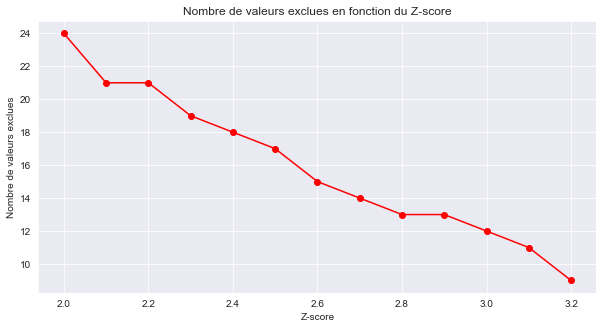

In [16]:
df = doubs_data.copy()

excluded_counts = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df_filtered = df.copy()

    df_filtered['z_score'] = np.abs(zscore(df_filtered['duree_minutes']))

    total_before = len(df_filtered)

    df_filtered = df_filtered[df_filtered['z_score'] <= z].drop(columns=['z_score'])

    total_after = len(df_filtered)

    excluded_count = total_before - total_after
    excluded_counts.append(excluded_count)

plt.figure(figsize=(10, 5))
plt.plot(z_values, excluded_counts, label="Nombre de valeurs exclues", marker='o', color='red')
plt.xlabel("Z-score")
plt.ylabel("Nombre de valeurs exclues")
plt.title("Nombre de valeurs exclues en fonction du Z-score")
plt.grid(True)
plt.show()

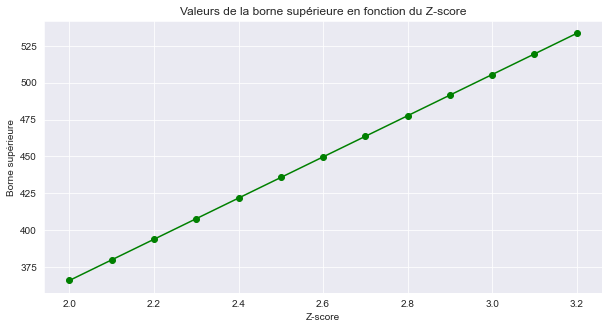

In [17]:
df = doubs_data.copy()

upper_bounds = []

z_values = np.arange(2.0, 3.2, 0.1)

for z in z_values:
    df['z_score'] = np.abs(zscore(df['duree_minutes']))

    upper_bound = df['duree_minutes'].mean() + z * df['duree_minutes'].std()

    upper_bounds.append(upper_bound)

plt.figure(figsize=(10, 5))
plt.plot(z_values, upper_bounds, label="Borne supérieure", marker='o', color='green')
plt.xlabel("Z-score")
plt.ylabel("Borne supérieure")
plt.title("Valeurs de la borne supérieure en fonction du Z-score")
plt.grid(True)
plt.show()

In [18]:
top_35_values = df['duree_minutes'].nlargest(35)

print(top_35_values)

1716    3885.850000
1199    3025.100000
1263    2753.933333
954     1725.383333
234     1667.683333
836     1629.883333
228     1625.983333
363     1500.500000
1112     920.333333
1341     531.866667
2583     530.733333
2590     510.183333
2853     504.333333
242      466.100000
2553     458.316667
160      443.816667
1931     437.516667
1173     435.516667
199      414.416667
2663     402.866667
505      398.400000
1804     373.866667
2419     371.916667
68       367.333333
1772     363.283333
260      359.183333
2778     358.000000
2767     357.716667
2816     355.216667
656      347.350000
0        345.533333
362      344.300000
937      342.533333
2297     331.250000
1009     326.916667
Name: duree_minutes, dtype: float64


In [19]:
doubs_data['z_score'] = np.abs(zscore(doubs_data['duree_minutes']))

doubs_data_filtered = doubs_data[doubs_data['z_score'] <= 2.9].drop(columns=['z_score'])

values_removed = len(doubs_data) - len(doubs_data_filtered)
print(f"Nombre de valeurs supprimées : {values_removed}")
print(f"Pourcentage des données supprimées : {values_removed / len(doubs_data) * 100:.2f}%")

Nombre de valeurs supprimées : 13
Pourcentage des données supprimées : 0.49%


In [20]:
doubs_data_filtered['date'] = pd.to_datetime(doubs_data_filtered['date'])
meteo_doubs['creneau'] = pd.to_datetime(meteo_doubs['creneau'])

meteo_doubs['geometry'] = [Point(xy) for xy in zip(meteo_doubs['longitude'], meteo_doubs['latitude'])]
meteo_gdf = gpd.GeoDataFrame(meteo_doubs, geometry='geometry', crs="EPSG:4326")

doubs_data_filtered = doubs_data_filtered.to_crs("EPSG:32631")
meteo_gdf = meteo_gdf.to_crs("EPSG:32631")

def trouver_meteo_proche(row, meteo_gdf):
    meteo_jour = meteo_gdf[meteo_gdf['creneau'] == row['date']]
    if meteo_jour.empty:
        return pd.Series([np.nan] * len(meteo_gdf.columns), index=meteo_gdf.columns)

    centroid = row.geometry.centroid
    centroid_x, centroid_y = centroid.x, centroid.y

    tree = cKDTree(np.array(list(zip(meteo_jour.geometry.x, meteo_jour.geometry.y))))
    dist, idx = tree.query([centroid_x, centroid_y], k=1)

    return meteo_jour.iloc[idx]

meteo_associee = doubs_data_filtered.apply(lambda row: trouver_meteo_proche(row, meteo_gdf), axis=1)

meteo_associee = meteo_associee.rename(columns={'geometry': 'geometry_meteo'})

doubs_data_filtered = pd.concat([doubs_data_filtered.reset_index(drop=True), meteo_associee.reset_index(drop=True)], axis=1)

doubs_data_filtered = doubs_data_filtered.loc[:, ~doubs_data_filtered.columns.duplicated()]

In [21]:
colonnes_a_supprimer = ['geometry_meteo', 'year', 'longitude', 'latitude', 'index', 'creneau']
doubs_data_filtered = doubs_data_filtered.drop(columns=colonnes_a_supprimer)

In [22]:
doubs_data_filtered = doubs_data_filtered.dropna()

In [23]:
test_size = 0.2
random_state = 42
hex_ids = doubs_data_filtered["hex_id"].unique()
splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
train_idx, test_idx = next(splitter.split(hex_ids, groups=hex_ids))
train_hex = hex_ids[train_idx]
test_hex = hex_ids[test_idx]
doubs_train = doubs_data_filtered[doubs_data_filtered["hex_id"].isin(train_hex)]
doubs_test = doubs_data_filtered[doubs_data_filtered["hex_id"].isin(test_hex)]
print(f"Taille du train : {doubs_train.shape[0]} lignes")
print(f"Taille du test : {doubs_test.shape[0]} lignes")

Taille du train : 1838 lignes
Taille du test : 487 lignes


In [24]:
common_hex = set(doubs_train["hex_id"]).intersection(set(doubs_test["hex_id"]))
if common_hex:
    print(f"Problème : {len(common_hex)} hex_id sont présents dans les deux datasets.")
else:
    print("Vérification réussie : Aucun hex_id en commun entre train et test.")

Vérification réussie : Aucun hex_id en commun entre train et test.


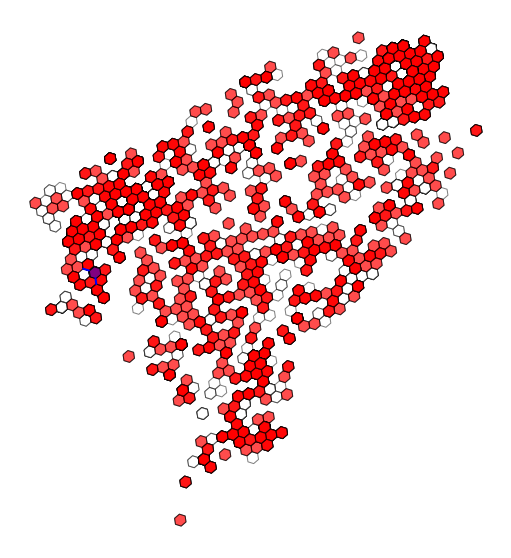

Distances minimales aux 6 hexagones les plus proches (par sommet) :
              hex_id    distance_km
3    871f82c73ffffff       0.000000
138  871f82c44ffffff       0.000000
184  871f82c46ffffff       0.000000
223  871f82c75ffffff       0.000000
306  871f82c74ffffff  148341.329495
182  871f82c55ffffff  149098.115610


In [25]:
hex_random = doubs_data_filtered.sample(1)

hex_vertices = list(hex_random.geometry.iloc[0].exterior.coords)

def extract_vertices(polygon):
    return list(polygon.exterior.coords)

hex_distances = {}

for idx, row in doubs_train.iterrows():
    if row.hex_id == hex_random.hex_id.iloc[0]:
        continue

    train_vertices = extract_vertices(row.geometry)

    min_distance = float("inf")
    closest_pair = None

    for v1 in hex_vertices:
        for v2 in train_vertices:
            d = Point(v1).distance(Point(v2))
            if d < min_distance:
                min_distance = d
                closest_pair = (v1, v2)

    if row.hex_id not in hex_distances or min_distance < hex_distances[row.hex_id][1]:
        hex_distances[row.hex_id] = (row.geometry, min_distance, closest_pair)

df_distances = gpd.GeoDataFrame(
    [(hex_id, geom, dist, pair) for hex_id, (geom, dist, pair) in hex_distances.items()],
    columns=["hex_id", "geometry", "distance", "closest_pair"],
    geometry="geometry"
)

df_distances["distance_km"] = df_distances["distance"] * 111

nearest_hex = df_distances[df_distances["distance_km"] <= 300000].nsmallest(6, "distance")

fig, ax = plt.subplots(figsize=(10, 10))

doubs_data_filtered.plot(ax=ax, color='white', edgecolor='black', alpha=0.5)

doubs_train.plot(ax=ax, color='red', edgecolor='black', alpha=0.7)

hex_random.plot(ax=ax, color='purple', edgecolor='black', alpha=1)

for _, row in nearest_hex.iterrows():
    x_values = [row.closest_pair[0][0], row.closest_pair[1][0]]
    y_values = [row.closest_pair[0][1], row.closest_pair[1][1]]
    ax.plot(x_values, y_values, color="blue", linewidth=2)

ax.set_axis_off()

plt.show()

print("Distances minimales aux 6 hexagones les plus proches (par sommet) :")
print(nearest_hex[["hex_id", "distance_km"]])

In [ ]:
def extract_vertices(polygon):
    return list(polygon.exterior.coords)

def find_nearest_neighbors(target_hex, all_hexagons, max_distance_km=300000):
    target_vertices = extract_vertices(target_hex.geometry)
    hex_distances = {}

    for idx, row in all_hexagons.iterrows():
        if row.hex_id == target_hex.hex_id:
            continue

        train_vertices = extract_vertices(row.geometry)

        min_distance = float("inf")
        for v1 in target_vertices:
            for v2 in train_vertices:
                d = Point(v1).distance(Point(v2))
                if d < min_distance:
                    min_distance = d

        distance_km = min_distance * 111
        if distance_km <= max_distance_km:
            hex_distances[row.hex_id] = distance_km

    nearest_neighbors = sorted(hex_distances.items(), key=lambda x: x[1])[:6]
    return [hex_id for hex_id, _ in nearest_neighbors]

for dataset in [doubs_train, doubs_test]:
    dataset["hex_voisins"] = dataset.apply(lambda _: [], axis=1)

    for idx, row in tqdm(dataset.iterrows(), total=dataset.shape[0], desc="Traitement des hexagones"):
        dataset.at[idx, "hex_voisins"] = find_nearest_neighbors(row, doubs_data_filtered)


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
Traitement des hexagones:  60%|█████▉    | 1098/1838 [1:00:35<40:32,  3.29s/it]

In [104]:
print("Type de 'hex_voisins' dans doubs_train:")
print(type(doubs_train['hex_voisins'].iloc[0]))

print("\nType de 'hex_voisins' dans doubs_test:")
print(type(doubs_test['hex_voisins'].iloc[0]))

Type de 'hex_voisins' dans doubs_train:
<class 'str'>

Type de 'hex_voisins' dans doubs_test:
<class 'str'>


In [106]:
doubs_train['hex_voisins'] = doubs_train['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
doubs_test['hex_voisins'] = doubs_test['hex_voisins'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

print(doubs_train['hex_voisins'].head())
print(doubs_test['hex_voisins'].head())

341    [871f82a2affffff, 871f82a05ffffff, 871f82a2bff...
343    [871f82040ffffff, 871f8204cffffff, 871f82044ff...
344    [871f80792ffffff, 871f82b6cffffff, 871f82b6dff...
345    [871f82c72ffffff, 871f82c55ffffff, 871f82c46ff...
347    [871f82b0dffffff, 871f82b2affffff, 871f82b01ff...
Name: hex_voisins, dtype: object
342    [871f82c0bffffff, 871f82c1dffffff, 871f82c72ff...
346    [871f82b68ffffff, 871f82b4cffffff, 871f82b6bff...
348    [871f82adeffffff, 871f82ad4ffffff, 871f82ac6ff...
357    [871f82885ffffff, 871f828a3ffffff, 871f828a8ff...
364    [871f82881ffffff, 871f828abffffff, 871f8288cff...
Name: hex_voisins, dtype: object


In [107]:
doubs_train['nombre_voisins'] = doubs_train['hex_voisins'].apply(lambda x: len(x) if isinstance(x, list) else 0)

doubs_test['nombre_voisins'] = doubs_test['hex_voisins'].apply(lambda x: len(x) if isinstance(x, list) else 0)

voisins_train = doubs_train['nombre_voisins'].value_counts().sort_index()
voisins_test = doubs_test['nombre_voisins'].value_counts().sort_index()

print("Nombre de voisins dans doubs_train:")
print(voisins_train)

print("\nNombre de voisins dans doubs_test:")
print(voisins_test)

Nombre de voisins dans doubs_train:
0       6
1       3
2       8
3      19
4      50
5     109
6    1643
Name: nombre_voisins, dtype: int64

Nombre de voisins dans doubs_test:
2      4
3     13
4     21
5     12
6    437
Name: nombre_voisins, dtype: int64


In [135]:
def get_statistics_for_neighbors(row, doubs_data):
    voisins_hex_ids = row['hex_voisins']

    filtered_df = doubs_data[doubs_data['hex_id'].isin(voisins_hex_ids)]

    statistics = {
        'voisins_moy': filtered_df['duree_minutes'].mean(),
        'voisins_medi': filtered_df['duree_minutes'].median(),
        'voisins_std': filtered_df['duree_minutes'].std(),
        'voisins_min': filtered_df['duree_minutes'].min(),
        'voisins_max': filtered_df['duree_minutes'].max(),
        'voisins_q1': filtered_df['duree_minutes'].quantile(0.25),
        'voisins_q3': filtered_df['duree_minutes'].quantile(0.75)
    }

    return statistics

for dataset in [doubs_train, doubs_test]:
    dataset[['voisins_moy', 'voisins_medi', 'voisins_std', 'voisins_min', 'voisins_max', 'voisins_q1', 'voisins_q3']] = dataset.apply(
        lambda row: pd.Series(get_statistics_for_neighbors(row, doubs_train)), axis=1)

print("Statistiques pour doubs_train :")
print(doubs_train[['voisins_moy', 'voisins_medi', 'voisins_std', 'voisins_min', 'voisins_max', 'voisins_q1', 'voisins_q3']].head())

print("\nStatistiques pour doubs_test :")
print(doubs_test[['voisins_moy', 'voisins_medi', 'voisins_std', 'voisins_min', 'voisins_max', 'voisins_q1', 'voisins_q3']].head())

TypeError: <lambda>() got an unexpected keyword argument 'axis'

In [131]:
doubs_train = doubs_train['duree_minutes'].fillna(0).copy()

statistics = {
    'voisins_moy': doubs_train.mean(),
    'voisins_medi': doubs_train.median(),
    'voisins_std': doubs_train.std(),
    'voisins_min': doubs_train.min(),
    'voisins_max': doubs_train.max(),
    'voisins_q1': doubs_train.quantile(0.25),
    'voisins_q3': doubs_train.quantile(0.75)
}

In [132]:
X_train = doubs_train.drop(columns=['duree_minutes', 'hex_id', 'colonne_a_ne_pas_utiliser'])
y_train = doubs_train['duree_minutes']

X_test = doubs_test.drop(columns=['duree_minutes', 'hex_id', 'colonne_a_ne_pas_utiliser'])
y_test = doubs_test['duree_minutes']

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

KeyError: 'duree_minutes'

In [134]:
doubs_train.columns

AttributeError: 'Series' object has no attribute 'columns'